# Legume testing
## Import

In [3]:
import meep as mp
from meep import mpb
import meep.materials as materials
import legume
import legume.viz
import legume.backend as bd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize as spo

import math

In [163]:
D=0.55
r=0.111
epsr=12

In [164]:
lattice = legume.Lattice("square")
phc = legume.PhotCryst(lattice)
phc.add_layer(d=D, eps_b=epsr)
phc.layers[-1].add_shape(legume.Circle(eps=1.0, r=r))
gme = legume.GuidedModeExp(phc, gmax=6)

Plane waves used in the expansion = 113.


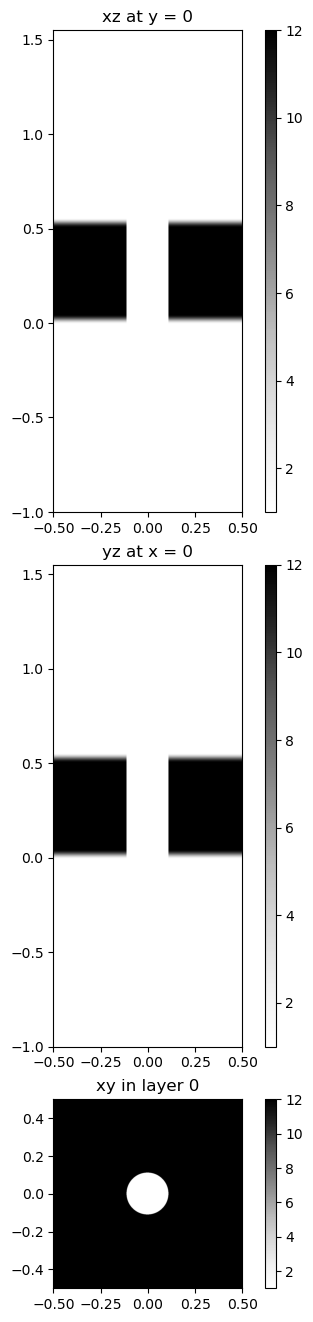

In [95]:
legume.viz.structure(phc, xz=True, yz=True, figsize=3, Ny=1000, Nx=1000)

In [91]:
path = lattice.bz_path([[0,0], [0.015,0], [0.0106, 0.0106], [0,0]], [40,1,40])
gme.run(kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3,4],
        numeig=2, 
        eig_sigma = 0.47656,
        verbose = True)

212.547s total time for real part of frequencies in GuidedModeExp, of which
  11.765s (6%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  162.139s (76%) for matrix diagionalization using the 'eigh' solver
  38.577s (18%) for creating GME matrix
1.047s  total time for imaginary part of frequencies███████│ 82 of 82


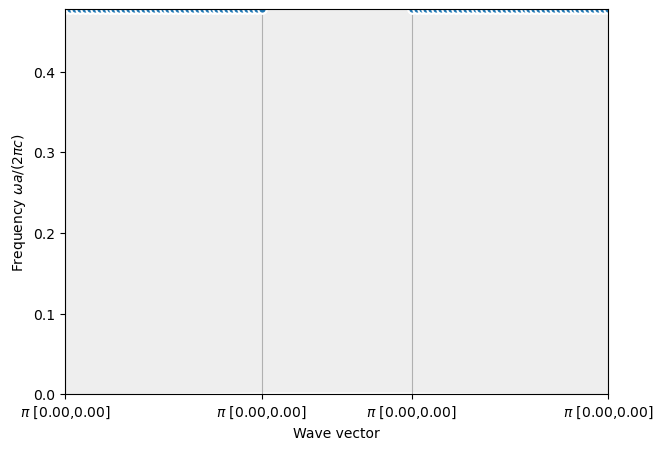

In [92]:
fig, ax = plt.subplots(1, figsize = (7, 5))
legume.viz.bands(gme, figsize=(5,5), k_units=True, Q=False, ax=ax, show_symmetry=True)
ax.set_xticks(path['k_indexes'])
ax.set_xticklabels(path['labels'])
ax.xaxis.grid('True')

In [93]:
gme.freqs

array([[0.47690126, 0.47690126],
       [0.47690126, 0.47690126],
       [0.47690125, 0.47690129],
       [0.47690124, 0.47690132],
       [0.47690123, 0.47690137],
       [0.47690122, 0.47690144],
       [0.4769012 , 0.47690152],
       [0.47690118, 0.47690161],
       [0.47690115, 0.47690172],
       [0.47690112, 0.47690184],
       [0.47690109, 0.47690198],
       [0.47690106, 0.47690213],
       [0.47690102, 0.4769023 ],
       [0.47690098, 0.47690248],
       [0.47690094, 0.47690267],
       [0.47690089, 0.47690288],
       [0.47690084, 0.4769031 ],
       [0.47690078, 0.47690334],
       [0.47690072, 0.47690359],
       [0.47690066, 0.47690386],
       [0.4769006 , 0.47690414],
       [0.47690053, 0.47690443],
       [0.47690046, 0.47690474],
       [0.47690039, 0.47690506],
       [0.47690031, 0.4769054 ],
       [0.47690023, 0.47690575],
       [0.47690015, 0.47690612],
       [0.47690006, 0.4769065 ],
       [0.47689997, 0.47690689],
       [0.47689987, 0.4769073 ],
       [0.

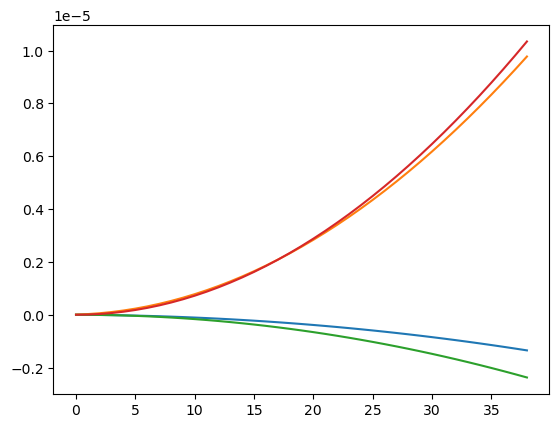

In [94]:
M=np.flip(gme.freqs[-40:-1],0)-gme.freqs[0][0]
X=gme.freqs[0:39]-gme.freqs[0][0]
plt.plot(M)
plt.plot(X)

In [97]:
gme.run(gmode_inds = [0,1,2,3,4,5,6],
        numeig=50,
        verbose = True)

0.317s total time for real part of frequencies in GuidedModeExp, of which
  0.026s (8%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  0.213s (67%) for matrix diagionalization using the 'eigh' solver
  0.078s (24%) for creating GME matrix
0.193s  total time for imaginary part of frequencies███████│ 1 of 1


In [99]:
test_freqs = gme.freqs[0]
test_freqs

array([3.37900056e-08, 4.44950374e-08, 3.35927130e-01, 3.36681706e-01,
       3.50792286e-01, 3.50792286e-01, 3.82383365e-01, 3.87441697e-01,
       3.87441697e-01, 3.94088524e-01, 4.51985821e-01, 4.53708534e-01,
       4.66615246e-01, 4.67332936e-01, 4.71543633e-01, 4.71543633e-01,
       4.76734463e-01, 4.76734463e-01, 4.82041402e-01, 4.93133154e-01,
       4.93133154e-01, 5.00789262e-01, 5.68087781e-01, 5.69889890e-01,
       5.75815261e-01, 5.82725002e-01, 5.84223387e-01, 5.84223387e-01,
       5.89621317e-01, 5.89621317e-01, 6.17290557e-01, 6.21057672e-01,
       6.27704950e-01, 6.27704950e-01, 6.33952440e-01, 6.38402004e-01,
       6.38402004e-01, 6.46402795e-01, 6.50985914e-01, 6.52384180e-01,
       6.52384180e-01, 6.54204390e-01, 6.57290330e-01, 6.65250628e-01,
       6.78285145e-01, 6.79222941e-01, 6.79222941e-01, 6.79416105e-01,
       6.79416105e-01, 6.88509519e-01])

In [14]:
path = lattice.bz_path([[0,0], [0.015,0], [0.0106, 0.0106], [0,0]], [40,1,40])
band_locs = np.ndarray((20, 2, 40, 2))
for i in range(len(test_freqs)):
    gme.run(kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3,4,5,6],
        numeig=2, 
        eig_sigma = test_freqs[i],
        verbose = True)
    band_locs[i][0]=gme.freqs[0:40]
    band_locs[i][1]=np.flip(gme.freqs[-41:-1], 0)

27.491s total time for real part of frequencies in GuidedModeExp, of which
  3.739s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  18.047s (66%) for matrix diagionalization using the 'eigh' solver
  5.675s (21%) for creating GME matrix
0.654s  total time for imaginary part of frequencies███████│ 82 of 82
26.845s total time for real part of frequencies in GuidedModeExp, of which
  3.720s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  17.677s (66%) for matrix diagionalization using the 'eigh' solver
  5.416s (20%) for creating GME matrix
0.645s  total time for imaginary part of frequencies███████│ 82 of 82
26.847s total time for real part of frequencies in GuidedModeExp, of which
  3.804s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-sp

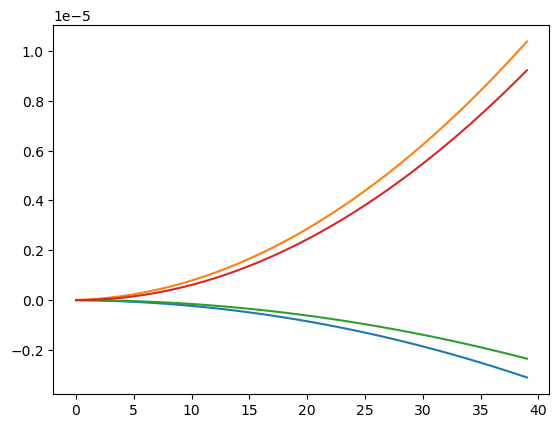

In [16]:
index = 17
M=band_locs[index][1]-band_locs[index][1][0][0]
X=band_locs[index][0]-band_locs[index][0][0][0]
plt.plot(M)
plt.plot(X)

In [100]:
vals, counts = np.unique(test_freqs.round(7), return_counts=True)
vals[counts>1]

array([0.       , 0.3507923, 0.3874417, 0.4715436, 0.4767345, 0.4931332,
       0.5842234, 0.5896213, 0.627705 , 0.638402 , 0.6523842, 0.6792229,
       0.6794161])

In [55]:
path = lattice.bz_path([[0,0], [0.015,0], [0.0106, 0.0106], [0,0]], [40,1,40])
band_locs = np.ndarray((len(vals[counts>1]), 2, 40, 2))
for i in range(len(vals[counts>1])):
    gme.run(kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3,4,5,6],
        numeig=2, 
        eig_sigma = vals[counts>1][i],
        verbose = True)
    band_locs[i][0]=gme.freqs[0:40]
    band_locs[i][1]=-np.flip(gme.freqs[-41:-1], 0)

28.586s total time for real part of frequencies in GuidedModeExp, of which
  3.813s (13%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  18.658s (65%) for matrix diagionalization using the 'eigh' solver
  6.087s (21%) for creating GME matrix
0.746s  total time for imaginary part of frequencies███████│ 82 of 82
26.510s total time for real part of frequencies in GuidedModeExp, of which
  3.772s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  16.969s (64%) for matrix diagionalization using the 'eigh' solver
  5.737s (22%) for creating GME matrix
0.748s  total time for imaginary part of frequencies███████│ 82 of 82
26.732s total time for real part of frequencies in GuidedModeExp, of which
  3.803s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-sp

/var/folders/rv/wdws79qj0xv_mhknwl94p2jh0000gn/T/ipykernel_95472/3316373643.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


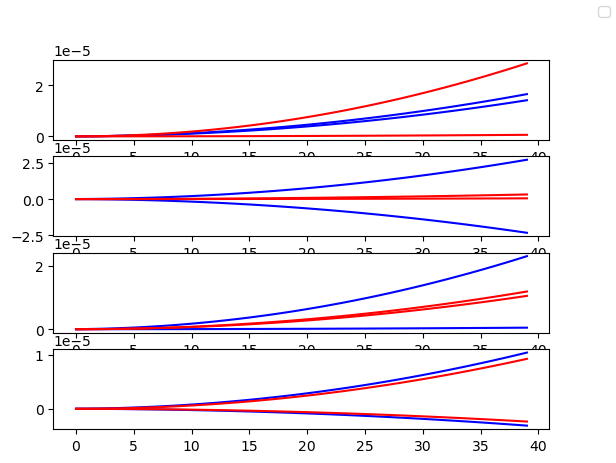

In [57]:
fig, ax = plt.subplots(len(vals[counts>1]))

for i in range(len(vals[counts>1])):
    M=-band_locs[i][1]+band_locs[i][1][0][0]
    X=band_locs[i][0]-band_locs[i][0][0][0]
    ax[i].plot(M, color = "blue")  
    ax[i].plot(X, color = "red")
fig.legend()



In [90]:
dist_to_band=abs(abs(band_locs[(band_locs.sum(axis=1)**2).sum(axis=(1,2)) == min((band_locs.sum(axis=1)**2).sum(axis=(1,2)))][0])-band_locs[(band_locs.sum(axis=1)**2).sum(axis=(1,2)) == min((band_locs.sum(axis=1)**2).sum(axis=(1,2)))][0][0][0]).min(axis=(0,2))
ks= np.array(range(40)) *0.015/40
np.polyfit(ks,dist_to_band, deg=2)[0]

np.float64(0.010981082402651126)

In [104]:
def key_vals(r):
    D=0.55
    epsr=12
    lattice = legume.Lattice("square")
    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=D, eps_b=epsr)
    phc.layers[-1].add_shape(legume.Circle(eps=1.0, r=r))
    gme = legume.GuidedModeExp(phc, gmax=6)

    gme.run(gmode_inds = [0,1,2,3,4,5,6],
        numeig=20,
        verbose = True)
    
    test_freqs = gme.freqs[0]
    vals, counts = np.unique(test_freqs.round(7), return_counts=True)
    test_vals = vals[counts>1]

    test_k = 0.015
    num_points = 40

    path = lattice.bz_path([[0,0], [test_k,0], [test_k/np.sqrt(2), test_k/np.sqrt(2)], [0,0]], [num_points,1,num_points])
    band_locs = np.ndarray((len(test_vals), 2, 40, 2))
    for i in range(len(test_vals)):
        gme.run(kpoints=path["kpoints"], 
            gmode_inds = [0,1,2,3,4,5,6],
            numeig=2, 
            eig_sigma = test_vals[i],
            verbose = True)
        band_locs[i][0]=gme.freqs[0:num_points]
        band_locs[i][1]=-np.flip(gme.freqs[-1*(num_points+1):-1], 0)
    
    aniso = (band_locs.sum(axis=1)**2).sum(axis=(1,2))

    chosen_band =abs(band_locs[aniso == min(aniso)][0])-band_locs[aniso == min(aniso)][0][0][0]
    dist_to_band = abs(chosen_band).min(axis=(0,2))
    ks = np.array(range(num_points)) * test_k/num_points

    a = np.polyfit(ks, dist_to_band, deg=2)[0]
    return a, np.sqrt(min(aniso))



    





In [102]:
key_vals(0.111)

Plane waves used in the expansion = 113.
Running gme k-points: │██████████████████████████████│ 1 of 1

0.324s total time for real part of frequencies in GuidedModeExp, of which
  0.028s (9%) for guided modes computation using the gmode_compute='exact' method
  0.002s (1%) for inverse matrix of Fourier-space permittivity
  0.216s (67%) for matrix diagionalization using the 'eigh' solver
  0.078s (24%) for creating GME matrix
0.198s  total time for imaginary part of frequencies███████│ 1 of 1
26.240s total time for real part of frequencies in GuidedModeExp, of which
  3.691s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  16.910s (64%) for matrix diagionalization using the 'eigh' solver
  5.612s (21%) for creating GME matrix
0.610s  total time for imaginary part of frequencies███████│ 82 of 82
26.420s total time for real part of frequencies in GuidedModeExp, of which
  3.761s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space p

(np.float64(0.010981082402651126), np.float64(1.880014112091982e-11))

In [192]:
path = lattice.bz_path([[0,0], [0.03,0], [0.0212, 0.0212], [0,0]], [40,1,40])


In [193]:
gme.run(kpoints=path["kpoints"], 
    gmode_inds = [0,1,2,3,4,5,6],
    numeig=2, 
    eig_sigma = max(vals[counts>1]),
    verbose = True)

26.482s total time for real part of frequencies in GuidedModeExp, of which
  3.668s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  17.163s (65%) for matrix diagionalization using the 'eigh' solver
  5.584s (21%) for creating GME matrix
0.697s  total time for imaginary part of frequencies███████│ 82 of 82


In [194]:
gme.run(kpoints=path["kpoints"],
    gmode_inds = [0,1,2,3,4,5,6],
    numeig=40, 
    verbose = True)

25.544s total time for real part of frequencies in GuidedModeExp, of which
  3.676s (14%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  16.630s (65%) for matrix diagionalization using the 'eigh' solver
  5.209s (20%) for creating GME matrix
12.622s  total time for imaginary part of frequencies██████│ 82 of 82


In [195]:
tot_freq = gme.freqs
test_freqs = tot_freq[0]
vals, counts = np.unique(test_freqs.round(7), return_counts=True)
test_vals = vals[(counts>1) & (vals != 0)]
test_vals

array([0.3507923, 0.3874417, 0.4715436, 0.4767345, 0.4931332, 0.5842234,
       0.5896213, 0.627705 , 0.638402 ])

In [196]:
mask = np.isin(test_freqs.round(7), test_vals)
mask

array([False, False, False, False,  True,  True, False,  True,  True,
       False, False, False, False, False,  True,  True,  True,  True,
       False,  True,  True, False, False, False, False, False,  True,
        True,  True,  True, False, False,  True,  True, False,  True,
        True, False, False, False])

In [197]:
masked = tot_freq.transpose()[mask]
masked

array([[0.35079229, 0.35079229, 0.35079229, ..., 0.35079243, 0.35079232,
        0.35079229],
       [0.35079229, 0.35079236, 0.35079259, ..., 0.35079245, 0.35079233,
        0.35079229],
       [0.3874417 , 0.3874417 , 0.3874417 , ..., 0.38744146, 0.38744164,
        0.3874417 ],
       ...,
       [0.62770495, 0.62770507, 0.62770545, ..., 0.62770524, 0.62770502,
        0.62770495],
       [0.638402  , 0.638402  , 0.63840201, ..., 0.63840177, 0.63840194,
        0.638402  ],
       [0.638402  , 0.63840205, 0.63840219, ..., 0.63840243, 0.63840211,
        0.638402  ]], shape=(18, 82))

In [214]:
band_locs = np.ndarray((len(test_vals), 2, 2, 40))

for i in range(len(test_vals)):
    band_locs[i][0]=masked[i*2:(i+1)*2, 0:40]
    band_locs[i][1]=-np.flip(masked[i*2:(i+1)*2, -1*(40+1):-1], 1)

band_locs.shape

aniso = (band_locs.mean(axis=1)**2).sum(axis=(1,2))

chosen_band =abs(band_locs[aniso == min(aniso)][0])-band_locs[aniso == min(aniso)][0][0][0][0]
dist_to_band = abs(band_locs).mean(axis=(1,2))
ks = np.array(range(40)) * 0.03/40

aniso


array([1.08815866e-08, 3.81362223e-08, 7.64539005e-09, 9.03565417e-11,
       6.61559963e-09, 3.17303190e-09, 3.15511931e-09, 2.41135640e-08,
       3.97195821e-08])

/var/folders/rv/wdws79qj0xv_mhknwl94p2jh0000gn/T/ipykernel_95472/1819501209.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


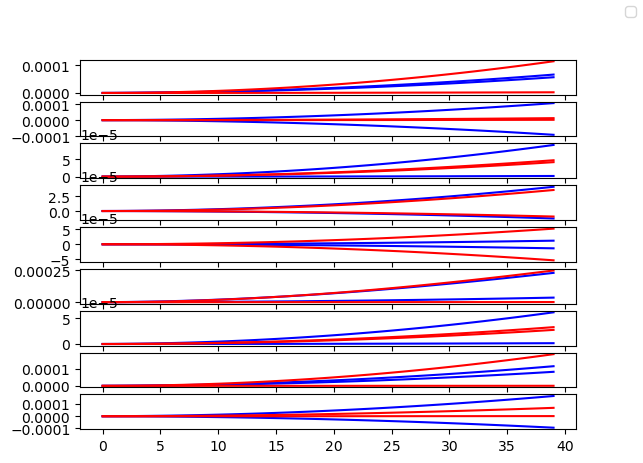

In [199]:
fig, ax = plt.subplots(len(test_vals))

for i in range(len(test_vals)):
    M=(-band_locs[i][1]+band_locs[i][1][0][0]).transpose()
    X=(band_locs[i][0]-band_locs[i][0][0][0]).transpose()
    ax[i].plot(M, color = "blue")  
    ax[i].plot(X, color = "red")
fig.legend()

In [207]:
def key_vals(r):
    D=0.55
    epsr=12
    lattice = legume.Lattice("square")
    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=D, eps_b=epsr)
    phc.layers[-1].add_shape(legume.Circle(eps=1.0, r=r))
    gme = legume.GuidedModeExp(phc, gmax=6)

    test_k = 0.03
    num_points = 40

    path = lattice.bz_path([[0,0], [test_k,0], [test_k/np.sqrt(2), test_k/np.sqrt(2)], [0,0]], [num_points,1,num_points])
    gme.run(
        kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3,4,5,6], 
        numeig=40,
        verbose = True
    )

    tot_freq = gme.freqs
    test_freqs = tot_freq[0]
    vals, counts = np.unique(test_freqs.round(7), return_counts=True)
    test_vals = vals[(counts>1) & (vals != 0)]

    mask = np.isin(test_freqs.round(7), test_vals)
    masked = tot_freq.transpose()[mask]

    band_locs = np.ndarray((len(test_vals), 2, 2, num_points))

    for i in range(len(test_vals)):
        band_locs[i][0]=masked[i*2:(i+1)*2, 0:num_points]
        band_locs[i][1]=-1*np.flip(masked[i*2:(i+1)*2, 1*(num_points+1):-1], 1)

    
    aniso = (band_locs.sum(axis=1)**2).sum(axis=(1,2))

    chosen_band =abs(band_locs[aniso == min(aniso)][0])-band_locs[aniso == min(aniso)][0][0][0][0]
    dist_to_band = abs(chosen_band).mean(axis=(0,1))
    ks = np.array(range(num_points)) * test_k/num_points

    a = np.polyfit(ks, dist_to_band, deg=2)[0]
    b = np.polyfit(ks, dist_to_band, deg=2)[1]
    omega = band_locs[aniso == min(aniso)][0][0][0][0]
    return omega, a,b, np.sqrt(min(aniso))

In [208]:
key_vals(0.111)

Plane waves used in the expansion = 113.
26.575s total time for real part of frequencies in GuidedModeExp, of which
  3.692s (14%) for guided modes computation using the gmode_compute='exact' method
  0.001s (0%) for inverse matrix of Fourier-space permittivity
  17.550s (66%) for matrix diagionalization using the 'eigh' solver
  5.304s (20%) for creating GME matrix
12.913s  total time for imaginary part of frequencies██████│ 82 of 82


(np.float64(0.47673446281749654),
 np.float64(0.028017140226145192),
 np.float64(3.1547116689919725e-05),
 np.float64(1.916369911685358e-05))

In [217]:
temp_data = np.ndarray((5,10))
temp_data[0]=1
temp_data

array([[1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
        1.       , 1.       , 1.       , 1.       ],
       [0.4519858, 0.4537085, 0.4666152, 0.4673329, 0.4715436, 0.4715436,
        0.4767345, 0.4767345, 0.4820414, 0.4931332],
       [0.4931332, 0.5007893, 0.5680878, 0.5698899, 0.5758153, 0.582725 ,
        0.5842234, 0.5842234, 0.5896213, 0.5896213],
       [0.6172906, 0.6210577, 0.627705 , 0.627705 , 0.6339524, 0.638402 ,
        0.638402 , 0.6464028, 0.6509859, 0.6523842],
       [0.6523842, 0.6542044, 0.6572903, 0.6652506, 0.6782851, 0.6792229,
        0.6792229, 0.6794161, 0.6794161, 0.6885095]])